In [20]:
from scipy.signal import stft
import scipy
import numpy as np
import matplotlib.pyplot as plt

rzeczy do dodania:
- stft
- sk (spectral kurtosis)
- Jarque-Bera statistic
- KSS (Kolmogorov-Smirnov statistic)
- Anderson-Darling statistic
- QQplot (visual)
- local maxima selector

# dane testowe


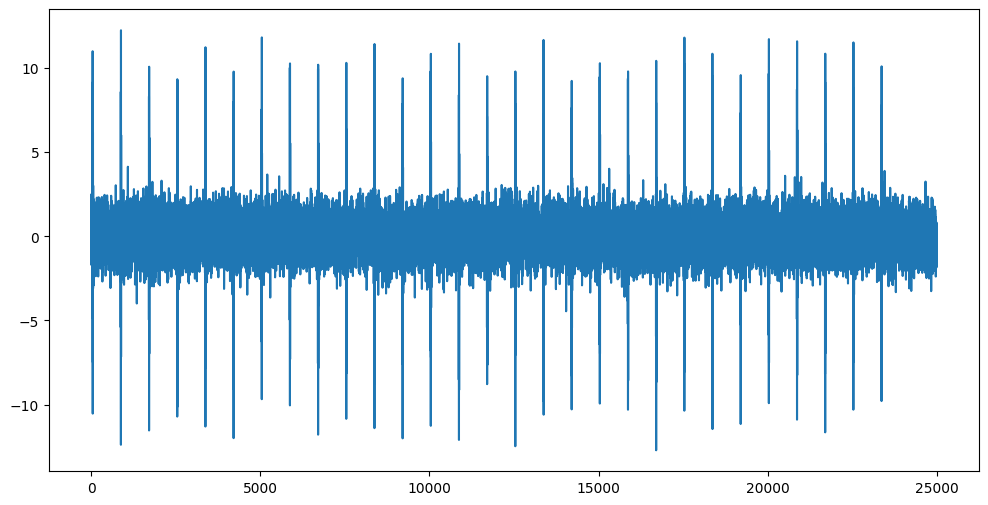

In [21]:
signal = np.loadtxt("assets/signal.csv")
plt.figure(figsize = (12 , 6))
plt.plot(signal)


# Short term Fourier Transform

In [22]:
array_freq, array_tt, matrix_Zxx =stft(signal, fs = 25000, window = 'hann')
Zxx = np.abs(matrix_Zxx)

# Cramer von Misses

In [10]:
def CVM(Zxx):
    F = Zxx.shape[0]
    T = Zxx.shape[1]
    results = np.zeros(F)
    for f in range(F):
        results[f] = scipy.stats.cramervonmises(Zxx[f],cdf="norm").statistic
    return results

cvm_results = CVM(Zxx)

        


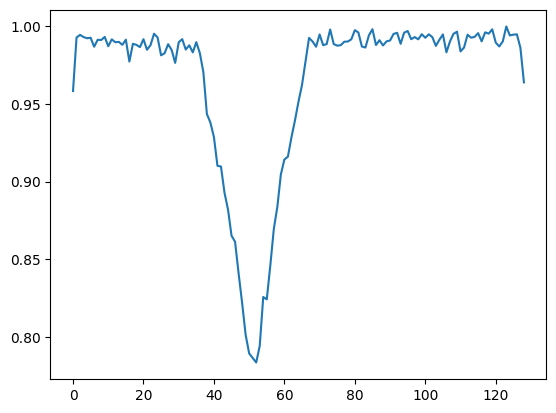

In [14]:
plt.plot(cvm_results/max(cvm_results))

# CVS (Conditional Variance Statistic)

Kroki w postępowaniu:
- Przujmyjemy że dany zbiór Y jest N(mi, sigma)
- dla pewnego 0 < q < 0.5 obliczamy kwantyl q, 1-q i to pomiędzy nimi, czyli z pdf L, R i M
- na podstawie tych zbiorów obliczamy sigmy elementów leżących w tych zbiorach
- mając te sigmy wstawiamy je do wzoru na statystykę testu

In [15]:
def cvs(signal,fs=25000,q=0.2):
    array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
    Zxx=abs(matrix_Zxx)
    F = Zxx.shape[0]
    T = Zxx.shape[1]

    results = np.zeros(F)
    for f in range(F):

        sorted_signal = np.sort(Zxx[f])
        lower_threshold = np.quantile(sorted_signal, q)
        upper_threshold = np.quantile(sorted_signal, 1-q)
        L = sorted_signal[sorted_signal <= lower_threshold]
        R = sorted_signal[sorted_signal > upper_threshold]
        M = sorted_signal[(lower_threshold < sorted_signal) & ( sorted_signal<= upper_threshold)]

        #obliczanie statystyki testowej N
        p=1

        N = 1/p * ((np.var(L)-np.var(M))/np.var(Zxx[0])+(np.var(R)-np.var(M))/np.var(Zxx[0])) * np.sqrt(len(Zxx[f]))

        results[f] = N

    return results


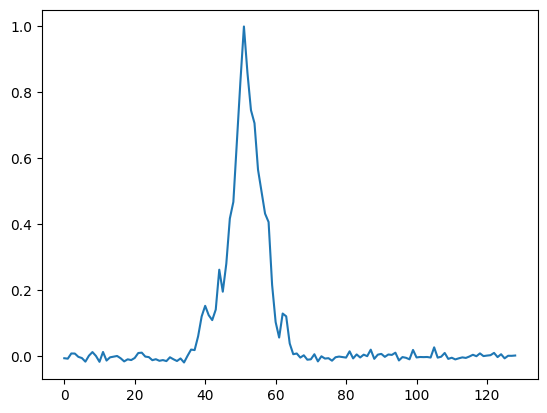

In [17]:
csv_results = cvs(signal)
plt.plot(csv_results/max(csv_results))

# H_max

In [41]:
def h_max(Zxx):
    F = Zxx.shape[0]
    T = Zxx.shape[1]
    results = np.zeros(F)

    def q(f,p):
        row = np.sort(Zxx[f])
        return np.percentile(row,p*100)
        
    for f in range(F):
        max_array = np.zeros(T)
        a = (scipy.stats.norm.ppf(0.75)-scipy.stats.norm.ppf(0.25))/(q(f,0.75) - q(f,0.25))
        b = scipy.stats.norm.ppf(0.75)-a*q(f,0.75) 
        S = np.sort(Zxx[f])
        
        for t in range(T):
            max_array[t] = scipy.stats.norm.ppf((2*(t+1)-1)/(2*T)) - a*S[t] - b
        results[f] = max(max_array)
    
    return results

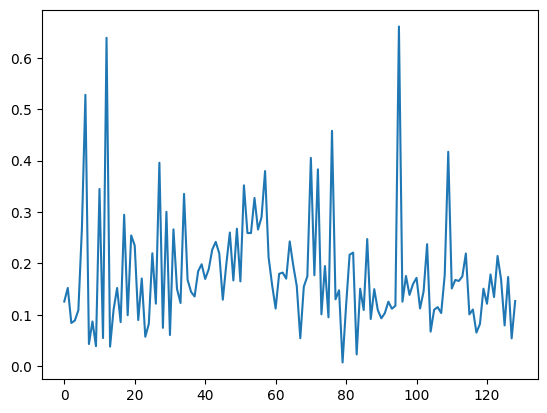

In [42]:
hmax_results = h_max(Zxx)
plt.plot(hmax_results)